In [32]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

## Helper functions

In [33]:

'''     
    Helper functions for loading and displaying images. 
'''
def load_image_rgb(path):
    """
        Load an image using OpenCV hence why it needs to be converted into RGB format because 
        OpenCV loads images in BGR format by default
    """
    image = cv2.imread(path)

    if image is None:
        raise FileNotFoundError(f"Could not load image from path: {path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image

def display_images(items, cmaps=None, figsize=None, suptitle=None):
    n = len(items)

    if figsize is None:
        figsize = (5 * n, 4)

    if cmaps is None:
        cmaps = [None] * n

    fig, axes = plt.subplots(1, n, figsize=figsize)

    if n == 1:
        axes = [axes]

    for ax, (img, title), cmap in zip(axes, items, cmaps):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    if suptitle:
        fig.suptitle(suptitle, fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()

def colorise_labels(labels):
    """
        Convert a watershed label image into an RGB image for visualisation.

        Label meanings:
        -1 = watershed boundary
        0 = unknown
        1 = background
        2, 3, 4, ... = object regions
    """

    max_label = int(labels.max()) + 1

    np.random.seed(42)

    palette = np.random.randint(
        60,
        220,
        size=(max(max_label + 1, 3), 3),
        dtype=np.uint8
    )

    palette[0] = [20, 20, 20]        # unknown = dark
    palette[1] = [180, 180, 180]     # background = grey

    rgb = np.zeros((*labels.shape, 3), dtype=np.uint8)

    for label in np.unique(labels):
        mask = labels == label

        if label == -1:
            rgb[mask] = [255, 0, 0]      # boundary = red
        elif 0 <= label < len(palette):
            rgb[mask] = palette[label]

    return rgb

## Loading the Raw Image

The first step is to load the original image. OpenCV loads images in BGR format, meaning the colour channels are ordered as Blue, Green, Red.

However, Matplotlib expects images in RGB format, meaning Red, Green, Blue.

So after loading the image with `cv2.imread`, we convert it using `cv2.cvtColor`.

This gives us the correct raw image that we will use throughout the watershed pipeline.

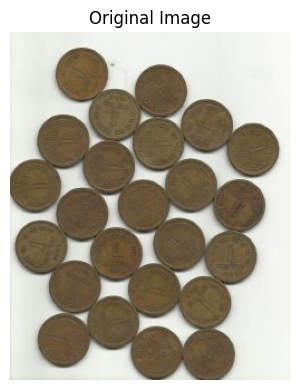

In [34]:
raw_image = load_image_rgb("./images/water_coins.jpg")
display_images([(raw_image, "Original Image")])

## Converting the Image to Grayscale

The raw image is an RGB image, so each pixel has three colour values: red, green, and blue.

For watershed segmentation, we usually simplify the image into grayscale. In grayscale, each pixel has only one intensity value.

This is useful because the next steps, such as thresholding and gradient computation, work more naturally on intensity values rather than full colour values.

At this point, we are not separating objects yet. We are only simplifying the image representation.

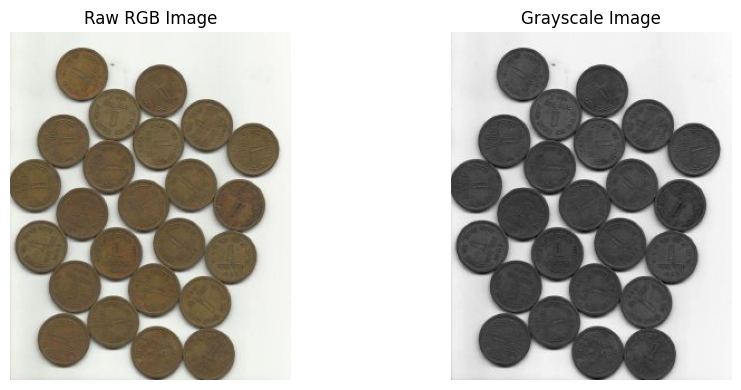

In [35]:
gray_image = cv2.cvtColor(raw_image, cv2.COLOR_RGB2GRAY)

display_images([(raw_image, "Raw RGB Image"), (gray_image, "Grayscale Image")], cmaps=[None, "gray"])

## Creating a Binary Image

The grayscale image still contains many different intensity values between 0 and 255.

To prepare for watershed segmentation, we first create a binary image from the grayscale image. A binary image only has two main values: black and white.

The white pixels represent the foreground objects that we want to segment because, in `cv2.threshold`, we pass `255` as the value assigned to pixels that satisfy the thresholding condition. Since `255` appears as white in a binary image, those selected pixels become the foreground. The remaining pixels are assigned `0`, which appears as black and represents the background.

Here, Otsu thresholding is used. Instead of manually choosing a threshold value, Otsu's method automatically finds a threshold that separates darker and brighter regions in the image. This happens because of the `cv2.THRESH_OTSU` flag.

Usint the `cv2.THRESH_BINARY_INV` flag, means inverse binary thresholding. This means that pixels darker than the threshold become white, while pixels brighter than the threshold become black. The inverse version is being used because the objects being segmented are darker than the background. This makes the objects appear as white foreground regions and the background appear black.

This step is important because the binary image will later be used to compute the distance transform and generate markers. Before moving on, I check that the objects I want to segment are white and the background is black.

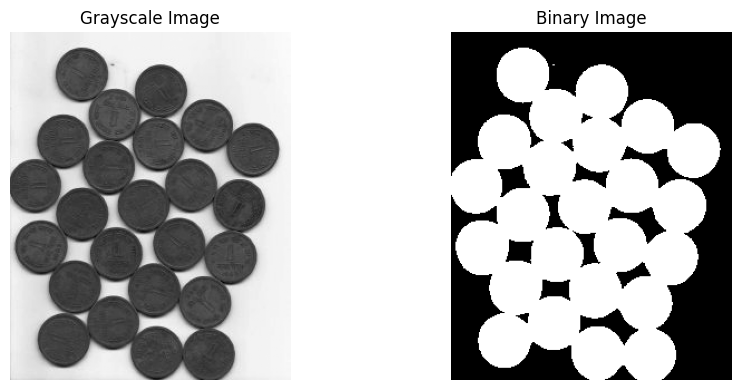

Otsu threshold value: 162.0


In [36]:
threshold_value, binary_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

display_images([(gray_image, "Grayscale Image"), (binary_image, "Binary Image")], cmaps=["gray", "gray"])

print("Otsu threshold value:", threshold_value)

## Applying the Distance Transform

After creating the binary image, the next step is to apply the distance transform.

At this point, the image has been simplified into two regions: the white pixels represent the foreground objects, and the black pixels represent the background.

The distance transform creates a new image where each foreground pixel stores a distance value. This value represents how far that pixel is from the nearest background pixel.

Internally, OpenCV estimates these distances by scanning through the image and updating each foreground pixel based on nearby pixels. The goal is that each white foreground pixel eventually stores its distance to the closest black background pixel.

Pixels close to the edge of an object are near the black background, so they receive small distance values. Pixels closer to the centre of an object are farther away from the background, so they receive larger distance values.

This is why the distance transform often makes the centre of each object appear brighter than its edges.

In this implementation, `cv2.DIST_L2` is used. This means OpenCV estimates the distance using Euclidean distance, which is the normal straight-line distance between two points.

The value `5` is the mask size. This means OpenCV uses a `5×5` local neighbourhood while estimating the distance values across the image. A `5×5` mask usually gives a more accurate Euclidean distance approximation than a smaller `3×3` mask.

This step is important for watershed segmentation because the brightest regions in the distance transform usually correspond to the safest inner parts of the objects. These regions are useful because they can become the starting markers for the watershed flooding process.

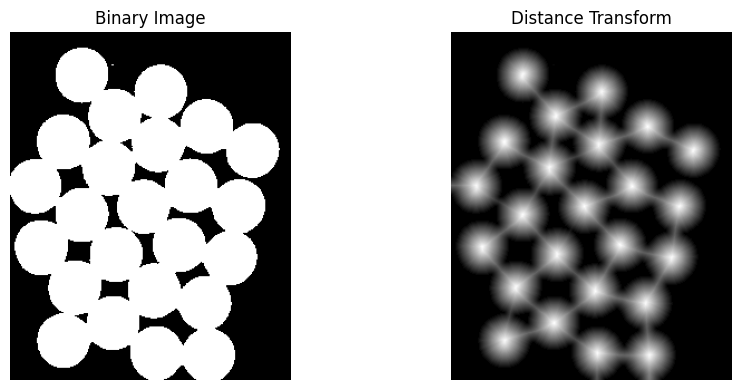

In [37]:
distance_transform = cv2.distanceTransform(binary_image, cv2.DIST_L2, 5)

display_images([(binary_image, "Binary Image"), (distance_transform, "Distance Transform")], cmaps=["gray", "gray"])

## Marker Generation

### Creating the Sure Foreground

The distance transform gives larger values to pixels that are closer to the centre of the foreground objects.

To create reliable object seeds, thresholding the distance transform is needed because it only keeps the pixels with high distance values, which are usually near the centre of each object.

These selected regions are called the sure foreground because they are very likely to belong to the objects and not to the background.

The threshold is chosen as a percentage of the maximum distance value. For example, using `0.5 * distance_transform.max()` means we keep only pixels whose distance value is at least 50% of the maximum distance found in the image.

If the percentage is too low, the foreground markers may become too large and merge together. If the percentage is too high, the markers may become too small or disappear.

These sure foreground regions will later be labelled using connected components so that each object seed receives its own marker label.

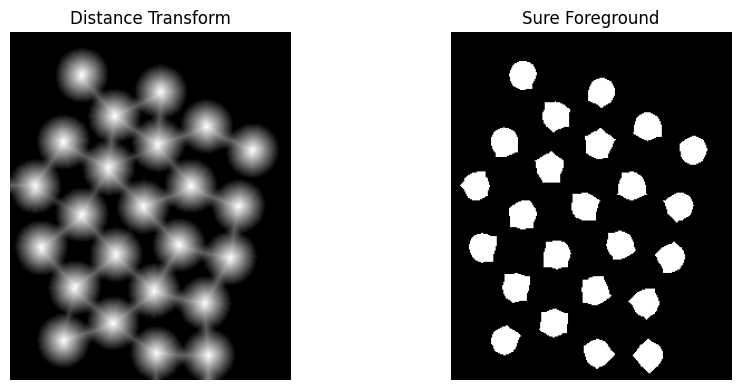

Maximum distance value: 23.968994
Threshold used: 11.984497


In [38]:
foreground_threshold_ratio = 0.5

_, sure_foreground = cv2.threshold(distance_transform, foreground_threshold_ratio * distance_transform.max(), 255, cv2.THRESH_BINARY)

sure_foreground = np.uint8(sure_foreground)

display_images([(distance_transform, "Distance Transform"),(sure_foreground, "Sure Foreground")], cmaps=["gray", "gray"])

print("Maximum distance value:", distance_transform.max())
print("Threshold used:", foreground_threshold_ratio * distance_transform.max())

### Creating the Sure Background and Unknown Region

After creating the sure foreground, the next step is to create a surrounding region and use it to identify the unknown area.

The sure foreground contains the safest centre parts of the objects, meaning the pixels that are most likely to belong to the objects. However, these centre regions are not enough on their own because watershed also needs to know which nearby pixels are still uncertain. These uncertain pixels are the ones that will be assigned during the flooding process.

To create this surrounding area, dilation is applied to the binary image. Dilation expands the white regions outward using a small kernel. The amount of expansion depends on the kernel size and the number of `iterations`. For example, with a `3×3` kernel, the kernel is placed over each pixel, and if white foreground pixels are found within that neighbourhood, the white region spreads into nearby pixels. This makes the foreground area slightly larger.

The unknown region is then created by subtracting the sure foreground from the dilated image. This removes the safe object centres and leaves the surrounding pixels around them. These remaining pixels are called unknown because they are usually close to object edges, touching regions, or possible boundaries.

During the flooding process, watershed expands the labelled markers into these unknown pixels and decides which region they should belong to. In simple terms, the sure foreground provides the safe starting points, while the unknown region provides the uncertain area that watershed needs to resolve.

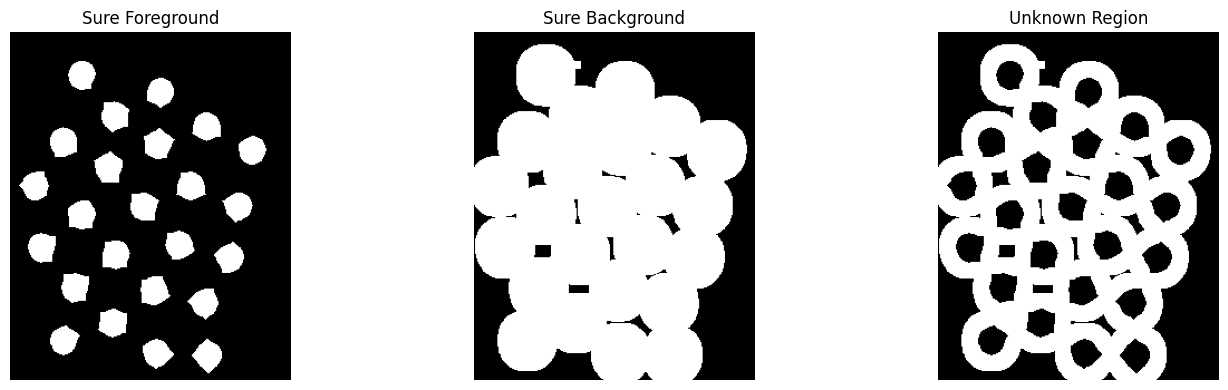

In [39]:
kernel = np.ones((3, 3), np.uint8)

sure_background = cv2.dilate(binary_image, kernel, iterations=3)

unknown_region = cv2.subtract(sure_background, sure_foreground)

display_images([(sure_foreground, "Sure Foreground"), (sure_background, "Sure Background"), 
                (unknown_region, "Unknown Region")], cmaps=["gray", "gray", "gray"])

### Creating Marker Labels

After creating the sure foreground and the unknown region, the next step is to convert the sure foreground regions into marker labels.

The sure foreground image contains the safest inner parts of the objects. However, at this stage, the image is still just a binary image, where foreground pixels are white and background pixels are black.

To use these regions as watershed starting points, each separate foreground region needs its own label. This is done using `cv2.connectedComponents`.

Connected components looks for separate white regions in the sure foreground image and assigns a different integer label to each one. These labels become the object markers, meaning they are the starting regions from which the watershed flooding process will expand.

The sure foreground is used to create the object labels because it contains the most reliable object centres. The sure background and unknown region are then used to adjust the marker image so watershed knows which pixels are already known and which pixels still need to be decided.

After connected components, the marker image is shifted up by one using `markers = markers + 1`. This makes label `1` represent the known background or non-object region, while labels `2`, `3`, `4`, and so on represent the object markers.

The unknown region is then set back to `0` using `markers[unknown_region == 255] = 0`. This is important because, in watershed, label `0` represents pixels that should not be trusted yet. These are the pixels that will be assigned later during the flooding process.

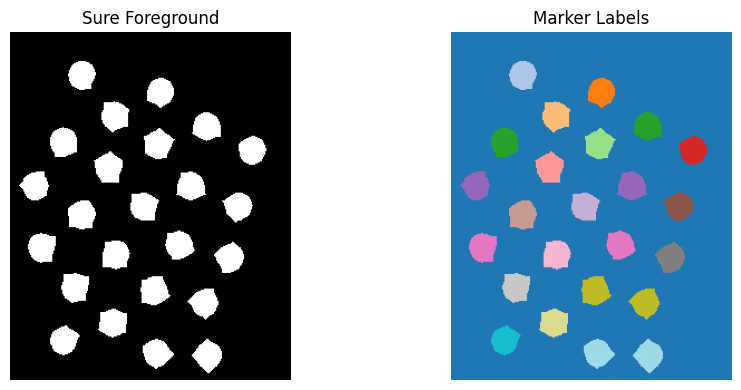

Number of connected components: 25
Unique marker labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


In [40]:
num_labels, markers = cv2.connectedComponents(sure_foreground)

markers = markers + 1 

markers[unknown_region == 255] = 0

display_images([(sure_foreground, "Sure Foreground"), (markers, "Marker Labels")], cmaps=["gray", "tab20"])

print("Number of connected components:", num_labels)
print("Unique marker labels:", np.unique(markers))

## Computing the Gradient Image

After creating the marker labels, the next step is to compute the gradient image.

The marker image tells the watershed algorithm where flooding should start, but the algorithm also needs a surface to flood over. This surface is created using a gradient image.

In this notebook, the gradient image is computed using the morphological gradient. This is one way of creating a gradient image for watershed. Other edge or gradient methods also exist, such as Sobel, Prewitt, Canny, and Laplacian.

The morphological gradient is used to highlight the outlines or edges of objects. It does this by looking at a small neighbourhood around each pixel. The size of this neighbourhood is controlled by the kernel chosen by the developer.

For each pixel, the algorithm looks at the surrounding pixels inside the kernel and finds two values: the highest pixel value in that neighbourhood and the lowest pixel value in that neighbourhood. It then subtracts them:

```text
morphological gradient = highest neighbourhood value - lowest neighbourhood value

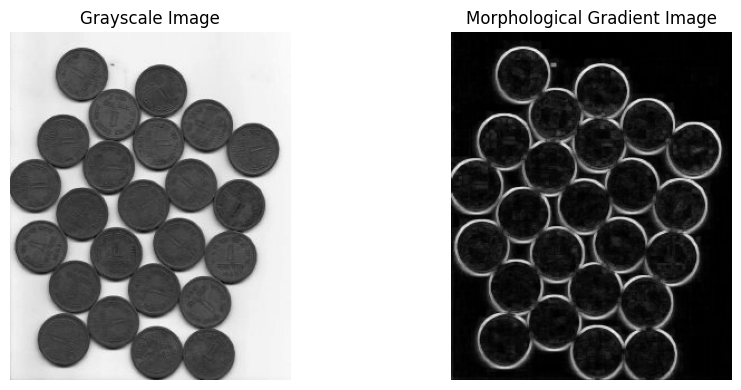

In [41]:
gradient_kernel = np.ones((3, 3), np.uint8)

gradient_image = cv2.morphologyEx(gray_image, cv2.MORPH_GRADIENT, gradient_kernel)

display_images([(gray_image, "Grayscale Image"), (gradient_image, "Morphological Gradient Image")], cmaps=["gray", "gray"])

## Preparing the Priority Queue for Flooding

After computing the gradient image, the next step is to prepare the pixels that will be used during flooding.

The gradient image acts like the terrain for the watershed algorithm. Low gradient values represent smooth areas, while high gradient values usually represent strong edges or object boundaries.

During watershed flooding, pixels with lower gradient values should be processed first because they are easier for regions to expand into. Pixels with higher gradient values are processed later because they are more likely to lie on boundaries.

To do this efficiently, a priority queue is used. Each pixel added to the queue is stored together with its gradient value. The gradient value becomes the priority.

This means the flooding process can always remove the pixel with the lowest gradient value first.

Conceptually, each queue entry stores: gradient value, row, column

In [42]:
def get_neighbors(row, col, height, width):
    """
        Return the 4-connected neighbours of a pixel.
    """

    neighbours = [
        (row - 1, col),  # up
        (row + 1, col),  # down
        (row, col - 1),  # left
        (row, col + 1)   # right
    ]

    valid_neighbours = []

    for r, c in neighbours:
        if 0 <= r < height and 0 <= c < width:
            valid_neighbours.append((r, c))

    return valid_neighbours

## Flooding implementation

After creating the marker labels and the gradient image, the next step is to simulate the watershed flooding process.

The marker image tells the algorithm where flooding starts. Pixels with labels greater than `0` are already known regions. Label `1` represents the background, while labels `2`, `3`, `4`, and so on represent object markers. Pixels labelled `0` are unknown and still need to be assigned.

The gradient image controls the order of flooding. Pixels with lower gradient values are processed first because they usually belong to smoother regions inside objects. Pixels with higher gradient values are processed later because they are more likely to lie near object boundaries.

A priority queue is used to make this process efficient. Each queue entry stores the gradient value of a pixel, its position, and the label that is trying to expand into it. Since the priority queue always removes the lowest gradient value first, the flooding naturally expands through smoother areas before reaching stronger edges.

The algorithm starts by adding the unknown neighbours of all existing markers into the priority queue. Then, while the queue is not empty, the lowest-gradient pixel is removed and assigned the label of the region that reached it.

If two different labelled regions try to reach the same area, this means the regions are competing for that pixel. In that case, the pixel is marked as `-1`, which represents a watershed boundary.

This implementation is a simplified educational version of watershed. It is useful for understanding the internal idea: markers define where flooding starts, the gradient image defines the terrain, and label conflicts create boundaries.

In [43]:
import heapq
import numpy as np

def manual_watershed_flooding(gradient_image, markers):
    height, width = gradient_image.shape

    labels = markers.copy()

    priority_queue = []

    #Add unkown neighbours of existing markers into the priority queue.
    for row in range(height):
        for col in range(width):

            #Only start from already labelled pixels.
            if labels[row, col] > 0:

                for n_row, n_col in get_neighbors(row, col, height, width):

                    #Only unknown neighbours need to be flooded.
                    if labels[n_row, n_col] == 0:

                        priority = gradient_image[n_row, n_col]

                        heapq.heappush(priority_queue,(priority, n_row, n_col, labels[row, col]))

    #Flood unknown pixels in order of increasing gradient value.
    while priority_queue:

        priority, row, col, incoming_label = heapq.heappop(priority_queue)

        #If the pixel is still unknown, assign it the incoming label.
        if labels[row, col] == 0:

            labels[row, col] = incoming_label

            #Add its unknown neighbours to the queue.
            for n_row, n_col in get_neighbors(row, col, height, width):

                if labels[n_row, n_col] == 0:

                    neighbour_priority = gradient_image[n_row, n_col]

                    heapq.heappush(priority_queue, (neighbour_priority, n_row, n_col, labels[row, col]))

                #If this neighbour already belongs to another region, then the current pixel lies between two competing regions.
                elif labels[n_row, n_col] > 0 and labels[n_row, n_col] != labels[row, col]:

                    labels[row, col] = -1

        #If another region already labelled this pixel before, check whether there is a label conflict.
        elif labels[row, col] > 0 and labels[row, col] != incoming_label:

            labels[row, col] = -1

    return labels

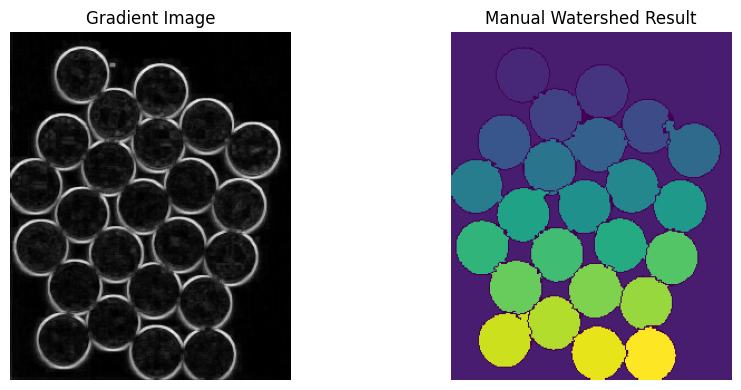

Unique labels: [-1  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


In [44]:
manual_labels = manual_watershed_flooding(gradient_image,markers)

display_images([(gradient_image, "Gradient Image"),(manual_labels, "Manual Watershed Result")], cmaps=["gray", None])

print("Unique labels:", np.unique(manual_labels))

The manual watershed function returns a label image. This label image is not a normal colour image. Instead, each pixel stores an integer label that represents which region it belongs to.

The labels have the following meaning:

```text
-1 = watershed boundary
 1 = background
 2, 3, 4, ... = object regions

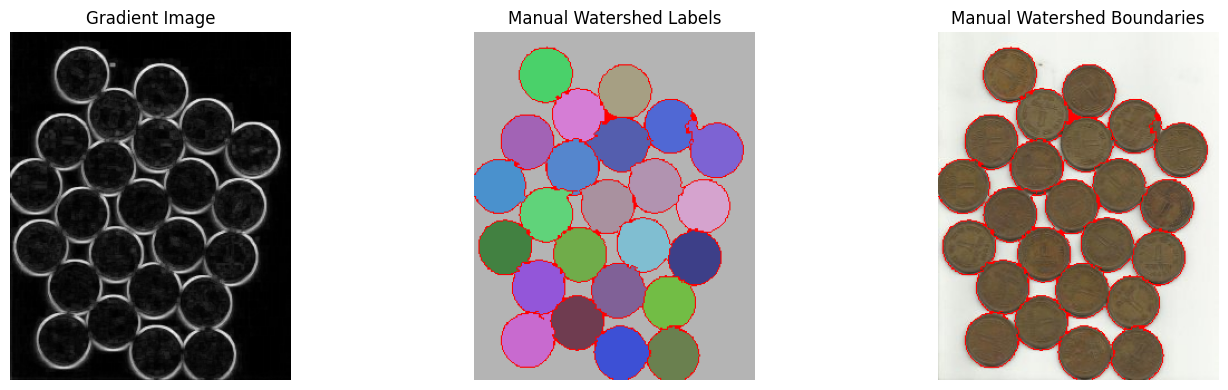

Unique labels in manual watershed result: [-1  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


In [45]:
manual_labels = manual_watershed_flooding(gradient_image, markers)

manual_coloured = colorise_labels(manual_labels)

boundary_overlay = raw_image.copy()
boundary_overlay[manual_labels == -1] = [255, 0, 0]

display_images([(gradient_image, "Gradient Image"), (manual_coloured, "Manual Watershed Labels"), 
                (boundary_overlay, "Manual Watershed Boundaries")], cmaps=["gray", None, None])

print("Unique labels in manual watershed result:", np.unique(manual_labels))

> **Note:** To experiment with this watershed pipeline visually, check the other file in this same directory called `app.py`.
>
> That file allows different parameter values to be changed interactively, so it becomes easier to see how each change affects the image at different stages of the pipeline.
>
> This is useful for understanding how choices such as threshold values, distance-transform settings, and marker generation affect the final watershed segmentation result.